<a href="https://colab.research.google.com/github/ritashreemukherjee123/Project-1-Applied-Search-Intelligence-Google-Search-Ranking-Discoverability.-/blob/main/work/w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


Attempting to load data from /content/gdrive/MyDrive/colab_outputs/features.parquet
Dataset 'features.parquet' loaded successfully.

Successfully loaded: features.parquet

First 5 rows of the dataset:


,as_of_date,client_hash_id,content_hash_id,impressions_90d,impressions_last30,impressions_prev30,clicks_last30,clicks_prev30,avg_position_last30,ga4_sessions_last30,...,content_type_keyword article,competition_level_HIGH,competition_level_LOW,competition_level_MEDIUM,competition_level_UNKNOWN_COMPETITION_LEVEL,main_intent_UNKNOWN_MAIN_INTENT,main_intent_commercial,main_intent_informational,main_intent_navigational,main_intent_transactional
0,2026-06-01,client_06d356715a8ff3b6,content_045a69625ade61a8,115.0,115.0,NaN,2.0,NaN,10.721739,2.0,...,True,False,True,False,False,False,False,True,False,False
1,2026-06-15,client_06d356715a8ff3b6,content_045a69625ade61a8,2868.0,2868.0,NaN,3.0,NaN,9.203543,7.0,...,True,False,True,False,False,False,False,True,False,False
2,2026-06-29,client_06d356715a8ff3b6,content_045a69625ade61a8,4785.0,4785.0,NaN,5.0,NaN,8.859272,12.0,...,True,False,True,False,False,False,False,True,False,False
3,2026-06-01,client_06d356715a8ff3b6,content_09063e5eace59644,605.0,605.0,NaN,18.0,NaN,3.685950,22.0,...,True,False,True,False,False,False,False,True,False,False
4,2026-06-15,client_06d356715a8ff3b6,content_09063e5eace59644,9790.0,9790.0,NaN,254.0,NaN,3.818047,263.0,...,True,False,True,False,False,False,False,True,False,False



Descriptive statistics of the dataset:


,as_of_date,impressions_90d,impressions_last30,impressions_prev30,clicks_last30,clicks_prev30,avg_position_last30,ga4_sessions_last30,active_days_90d,ctr_last30,...,has_category_count,has_keyword_char_count,has_keyword_token_count,has_url_char_count,has_avg_position_last30,has_ctr_last30,has_ctr_prev30,has_impression_ratio_last_vs_prev30,content_age_days_at_as_of,has_content_created_date
count,156778,156778.000000,156778.000000,0.0,156778.000000,0.0,156778.000000,156778.000000,156778.000000,156778.000000,...,156778.0,156778.0,156778.0,156778.0,156778.000000,156778.0,156778.0,156778.0,156778.000000,156778.0
mean,2026-06-20 04:49:33.907053,1938.032747,1938.032747,NaN,11.200060,NaN,12.692987,15.337694,19.980533,0.014615,...,1.0,1.0,1.0,1.0,0.999369,1.0,0.0,0.0,196.107962,1.0
min,2026-06-01 00:00:00,1.000000,1.000000,NaN,1.000000,NaN,0.000000,0.000000,1.000000,0.000032,...,1.0,1.0,1.0,1.0,0.000000,1.0,0.0,0.0,0.000000,1.0
25%,2026-06-15 00:00:00,191.000000,191.000000,NaN,1.000000,NaN,6.103527,0.000000,15.000000,0.002939,...,1.0,1.0,1.0,1.0,1.000000,1.0,0.0,0.0,81.000000,1.0
50%,2026-06-15 00:00:00,546.000000,546.000000,NaN,2.000000,NaN,8.740223,3.000000,15.000000,0.005663,...,1.0,1.0,1.0,1.0,1.000000,1.0,0.0,0.0,150.000000,1.0
75%,2026-06-29 00:00:00,1563.000000,1563.000000,NaN,7.000000,NaN,15.667487,9.000000,29.000000,0.011086,...,1.0,1.0,1.0,1.0,1.000000,1.0,0.0,0.0,306.000000,1.0
max,2026-06-29 00:00:00,601619.000000,601619.000000,NaN,146183.000000,NaN,213.666667,222024.000000,34.000000,1.000000,...,1.0,1.0,1.0,1.0,1.000000,1.0,0.0,0.0,584.000000,1.0
std,NaN,6377.217334,6377.217334,NaN,606.312258,NaN,10.540206,919.309766,9.521235,0.055401,...,0.0,0.0,0.0,0.0,0.025121,0.0,0.0,0.0,141.685668,0.0



Generating distributions for 35 numerical columns. Look for heavy tails.


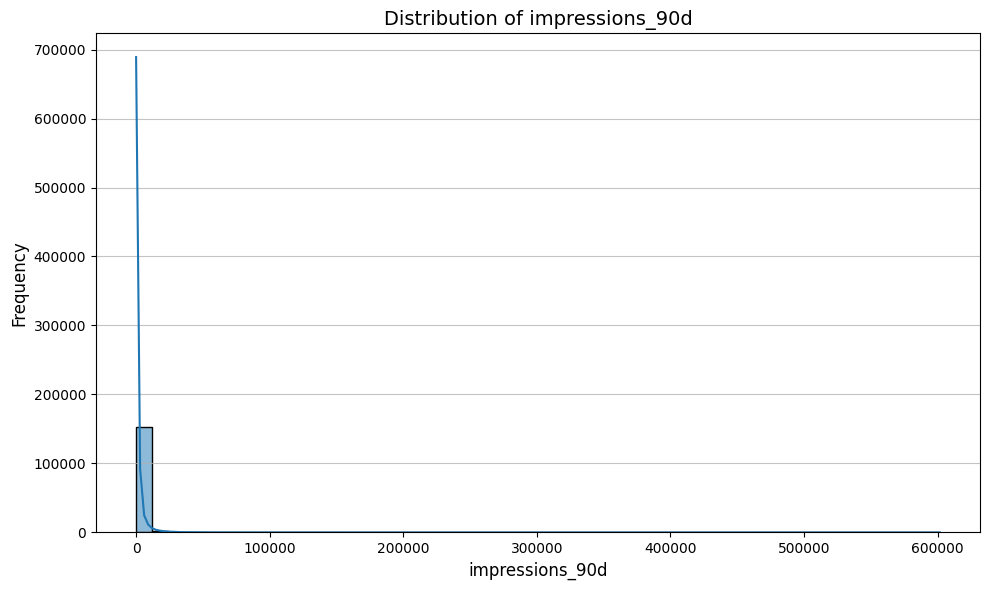

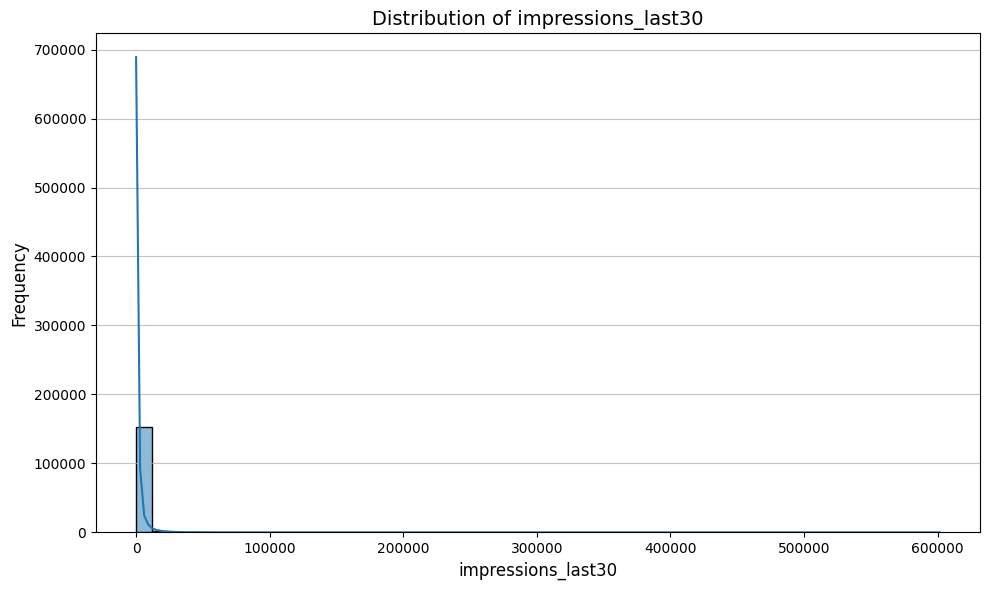

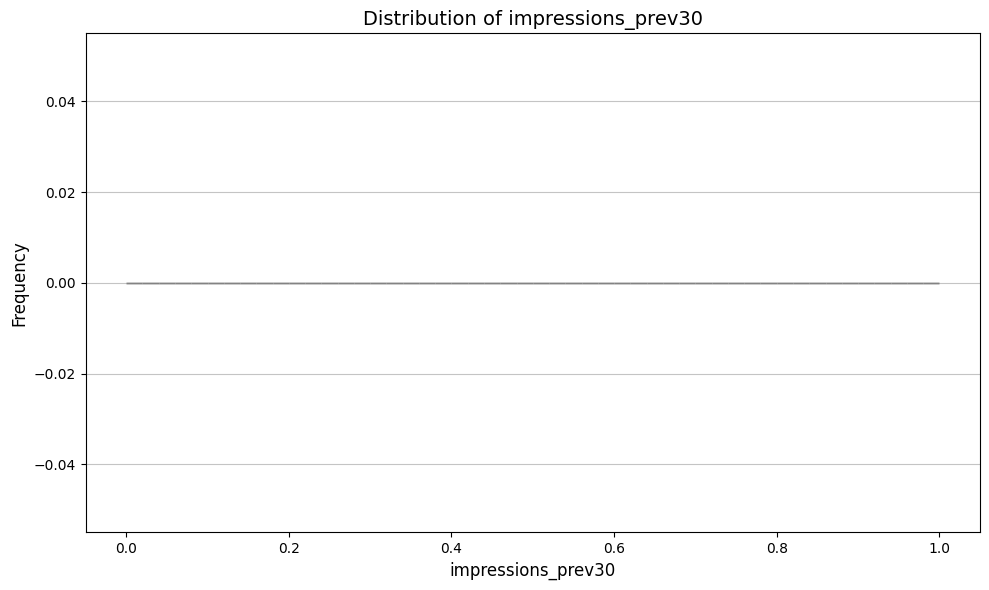

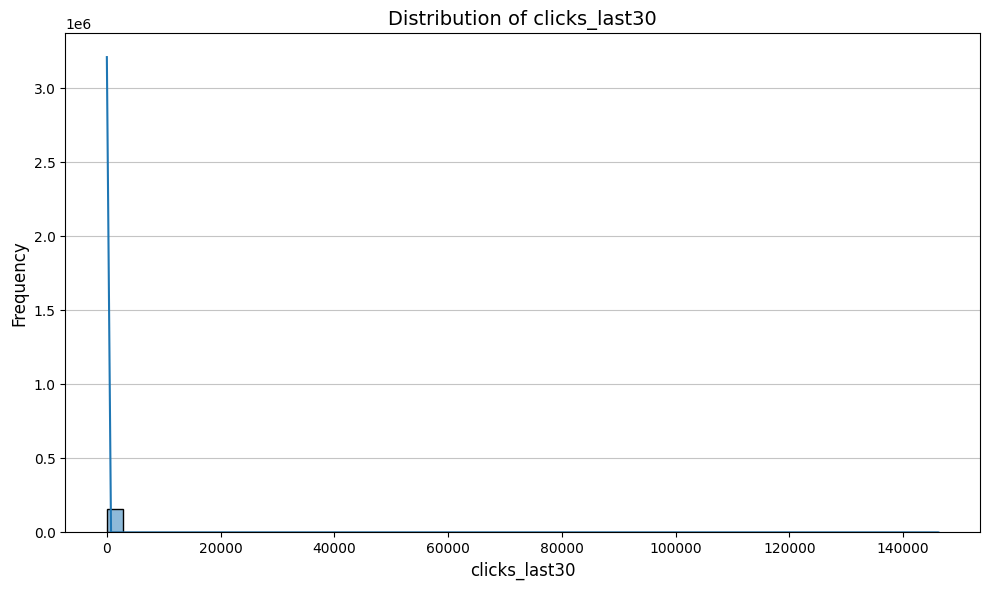

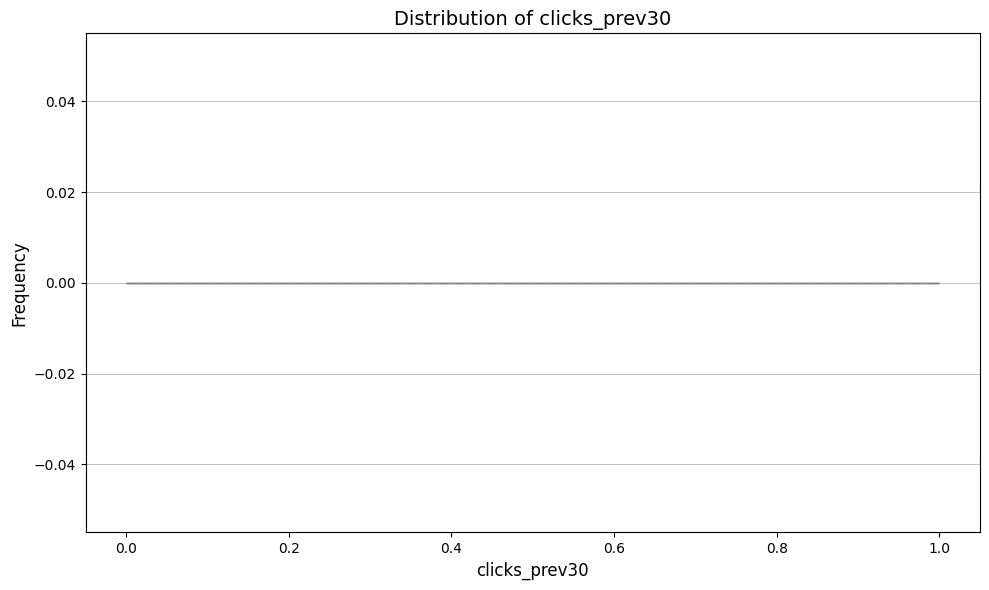

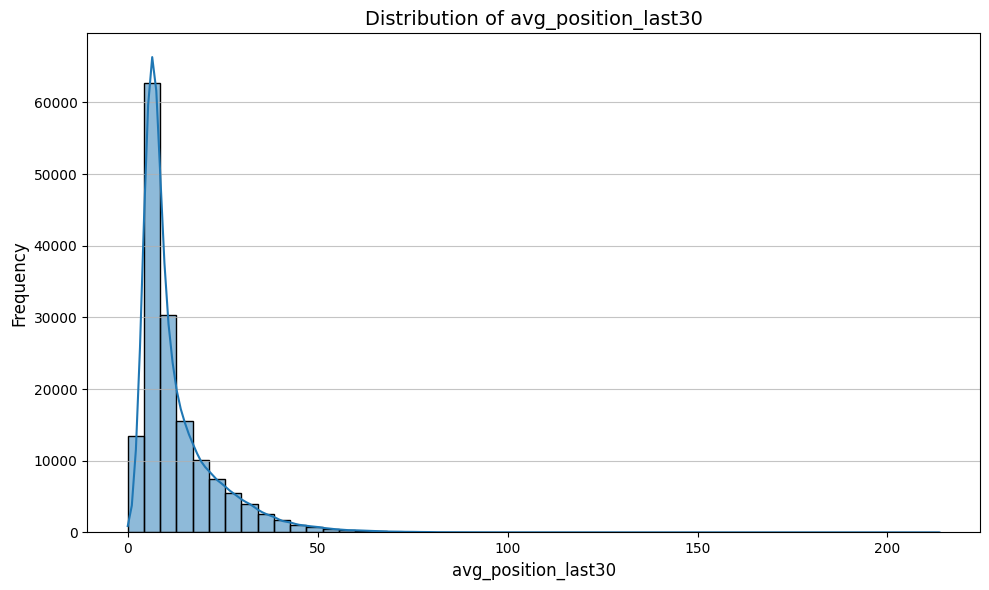

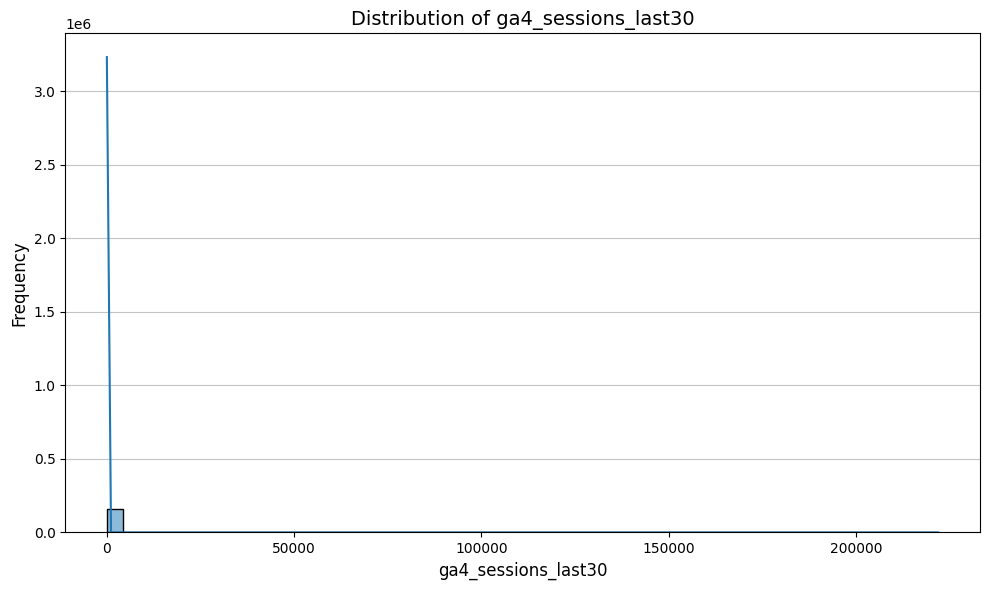

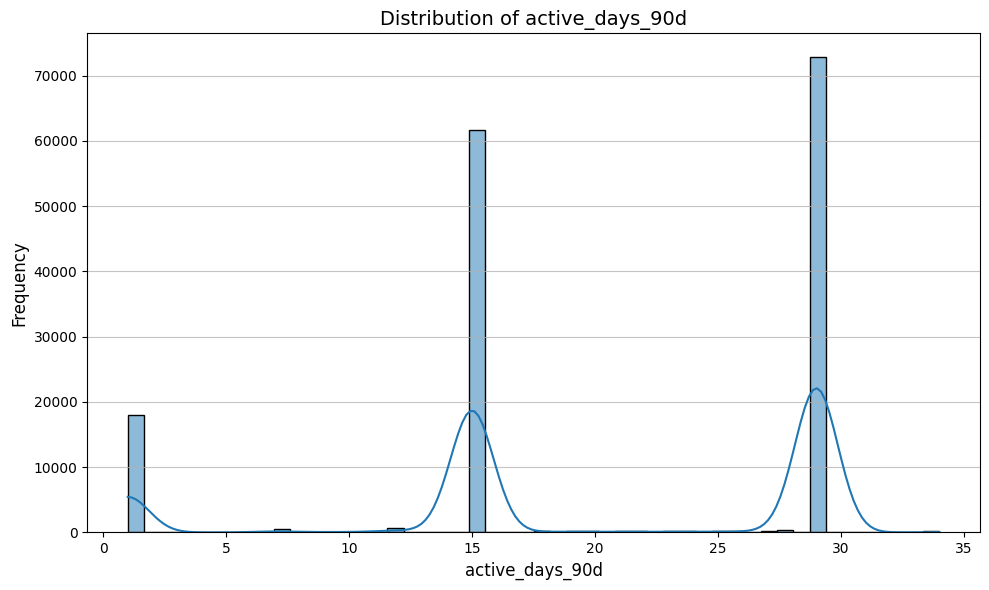

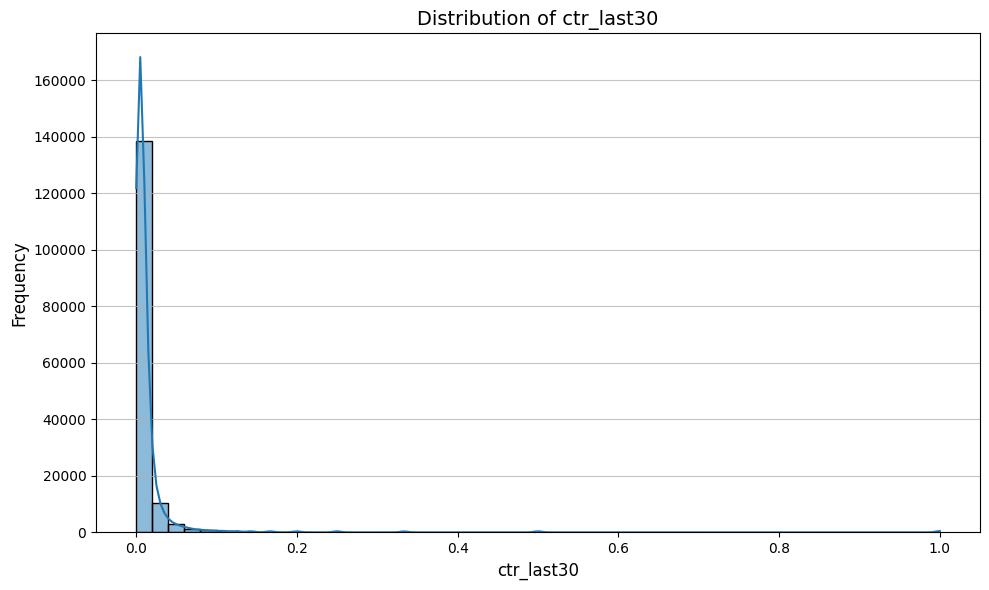

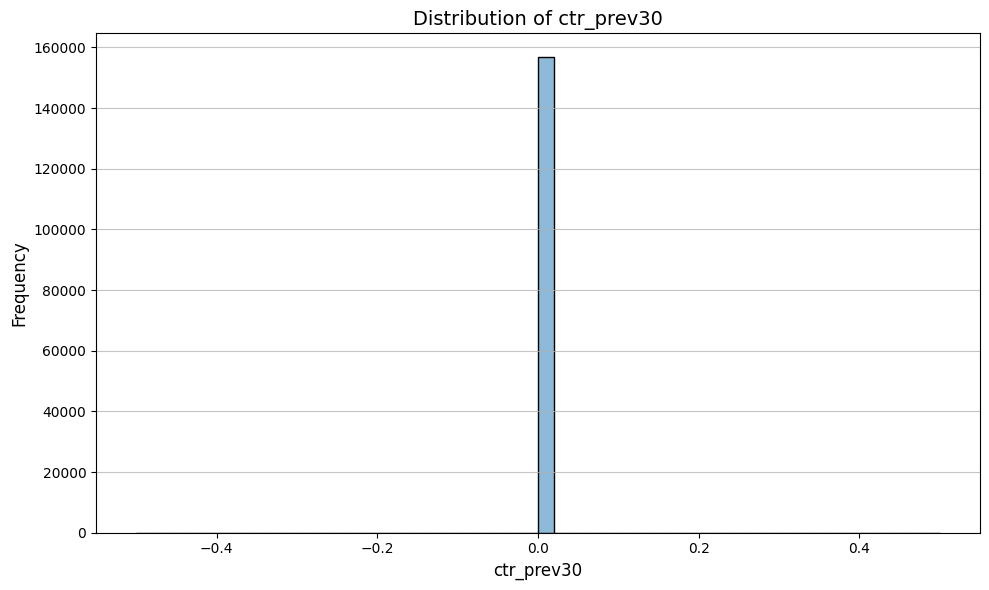

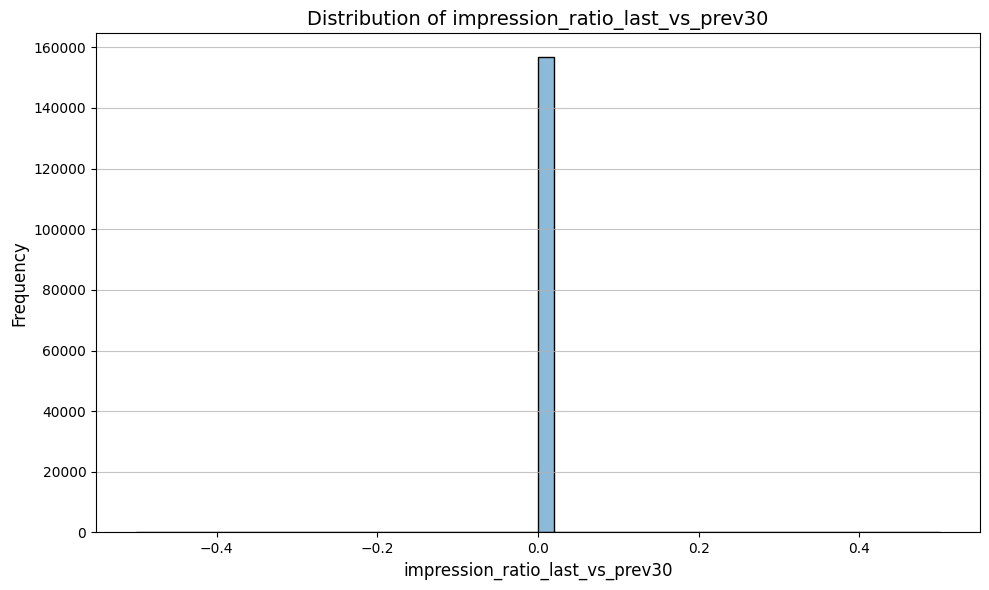

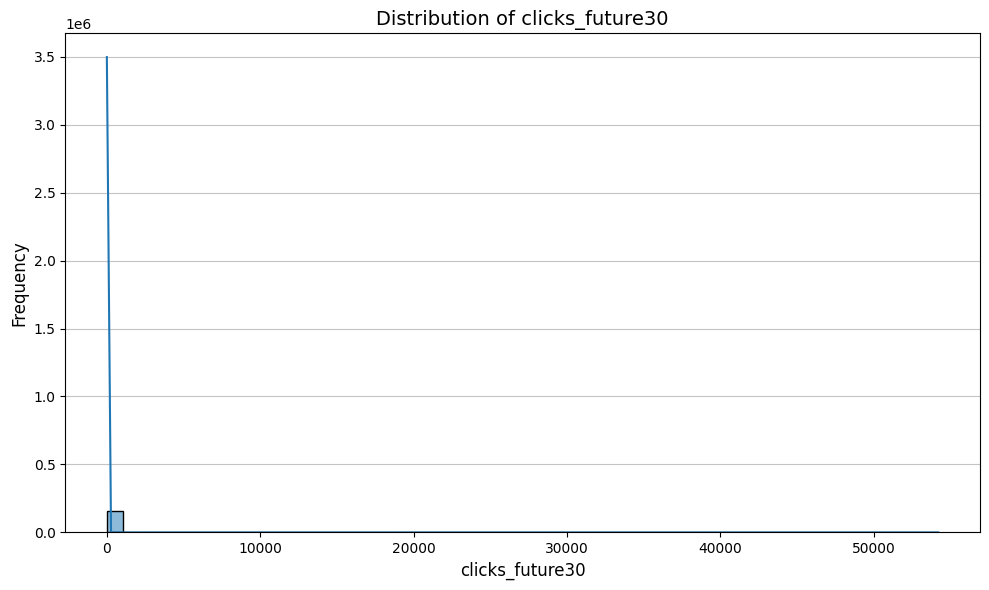

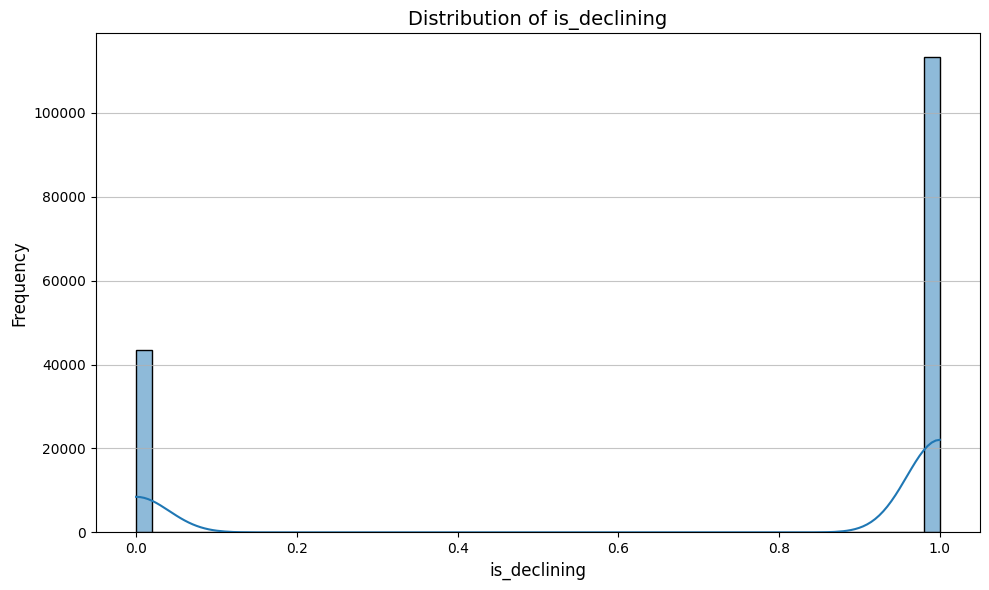

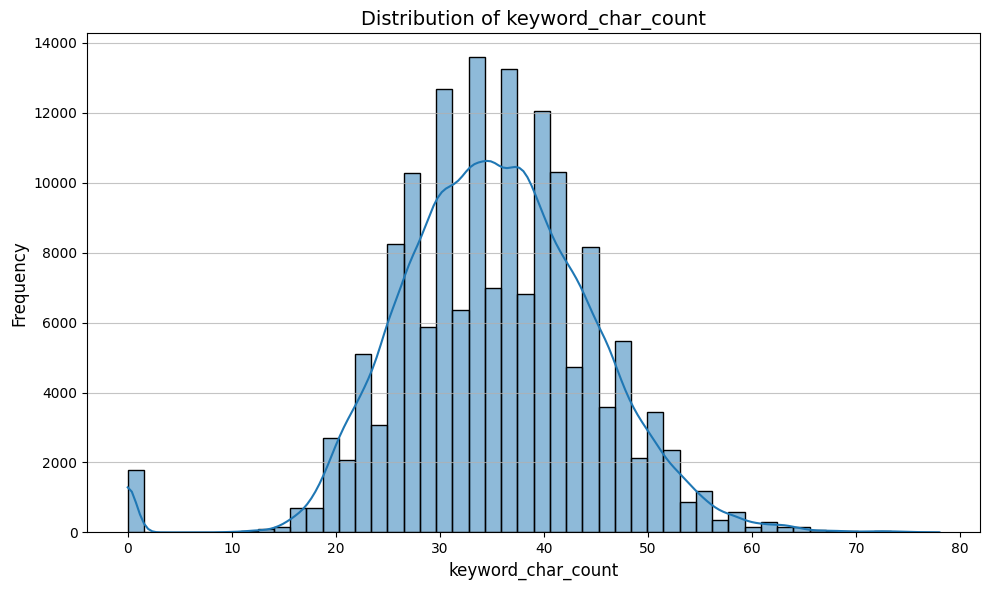

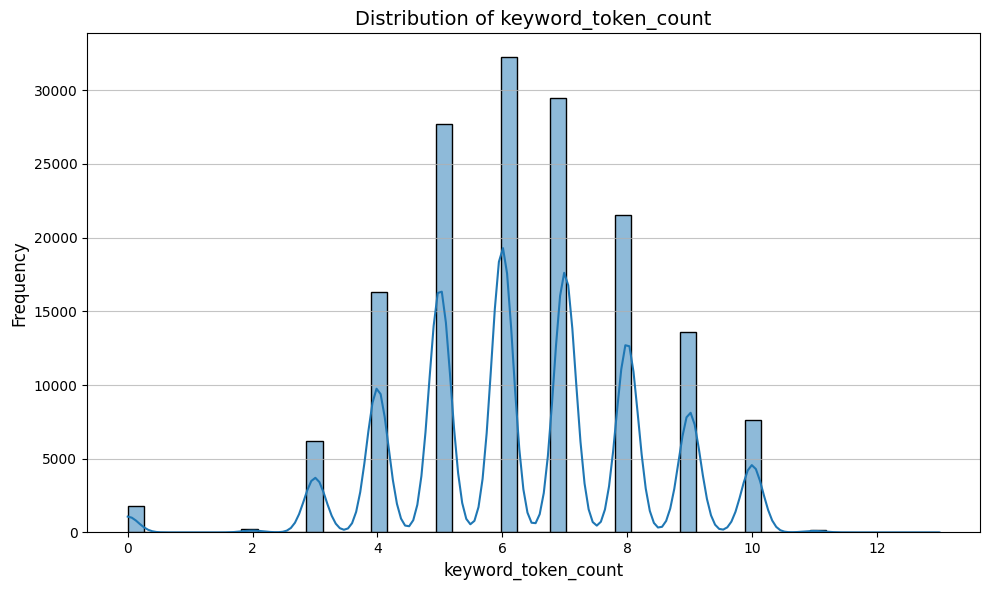

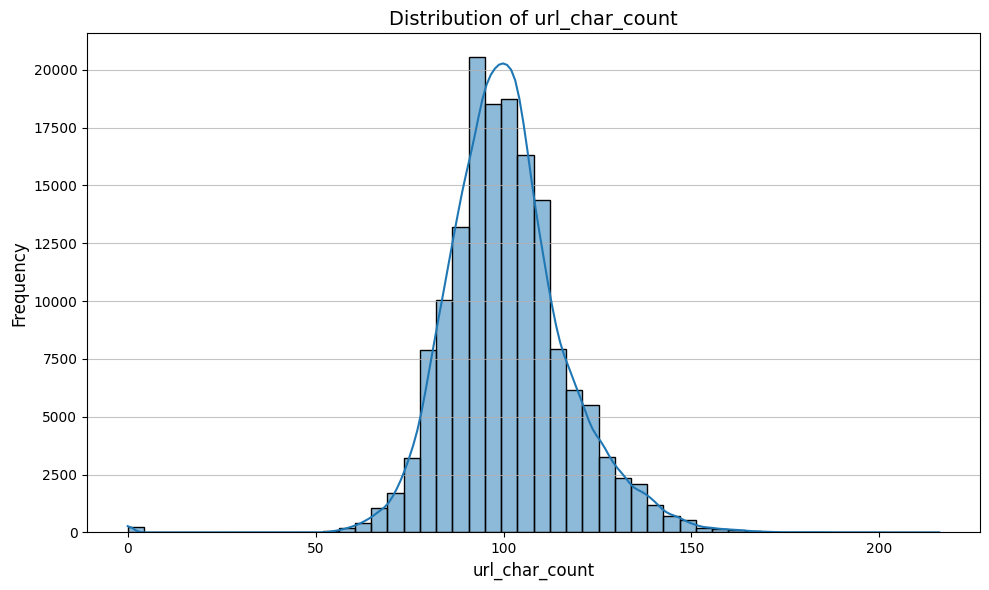

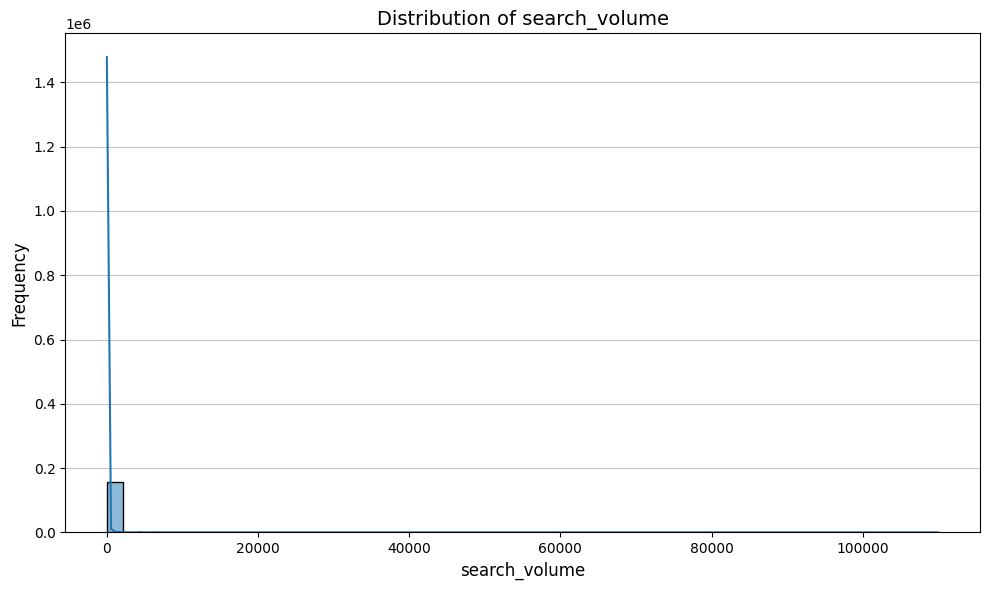

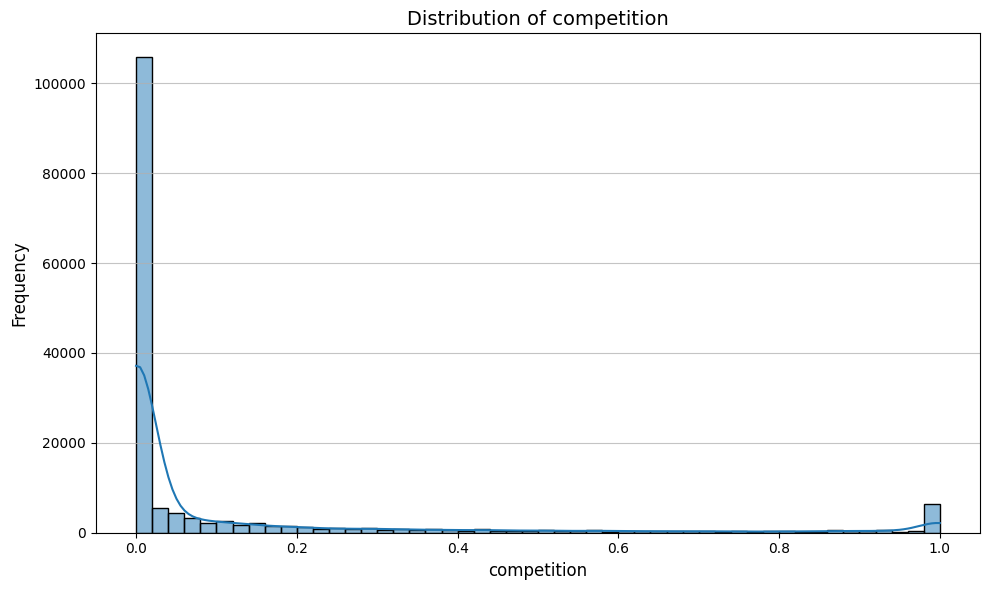

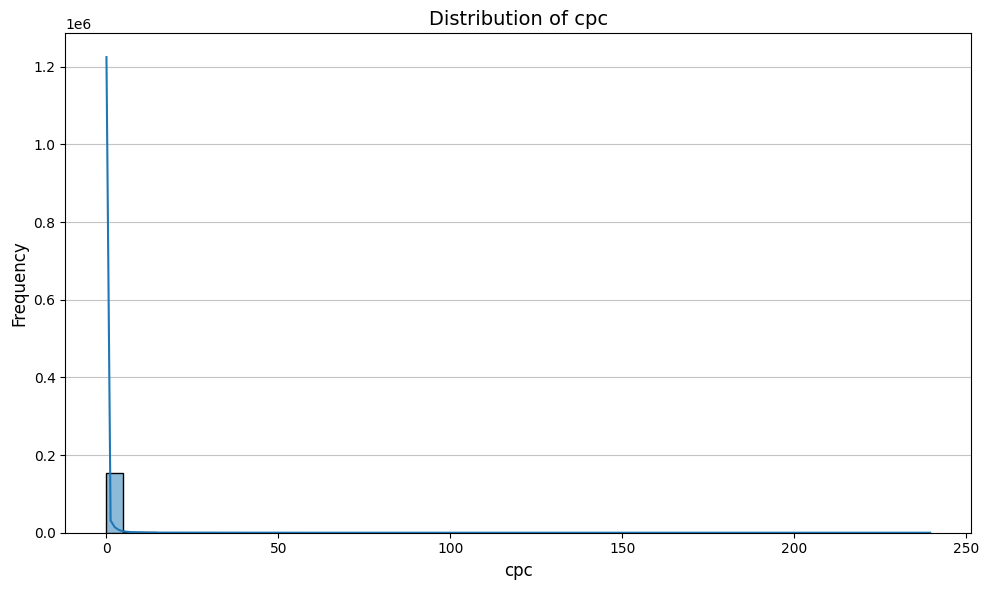

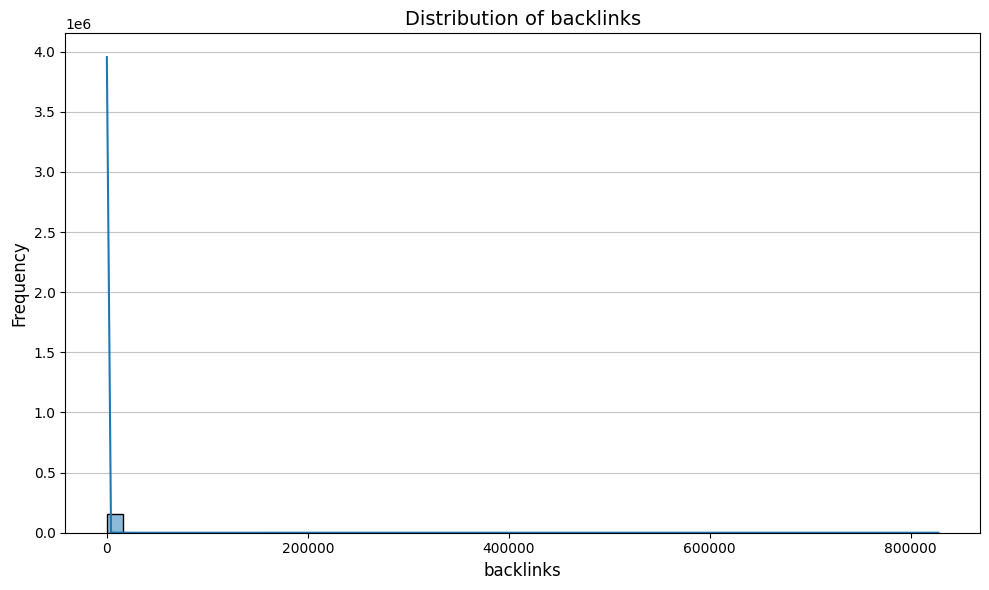

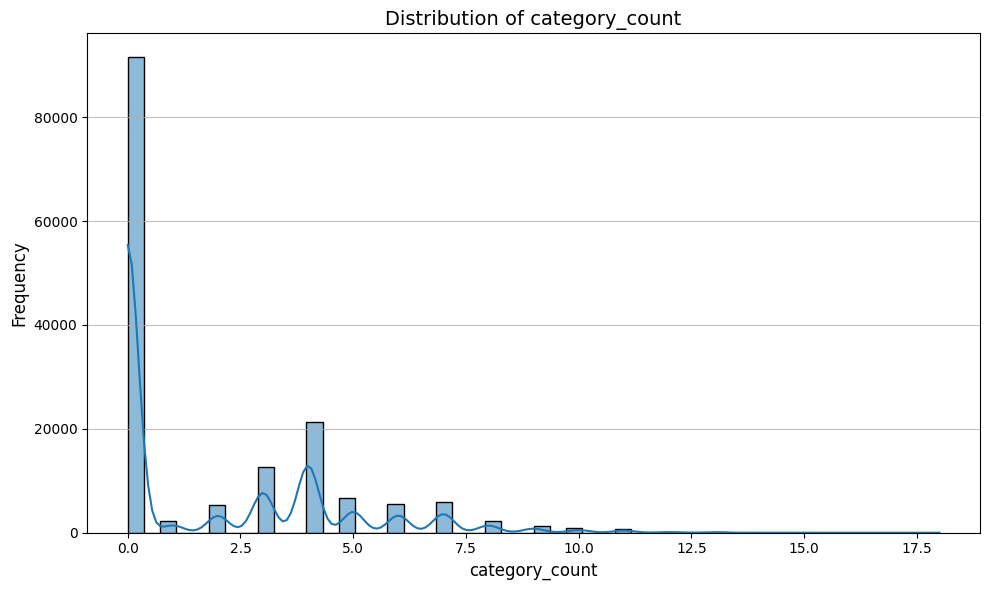

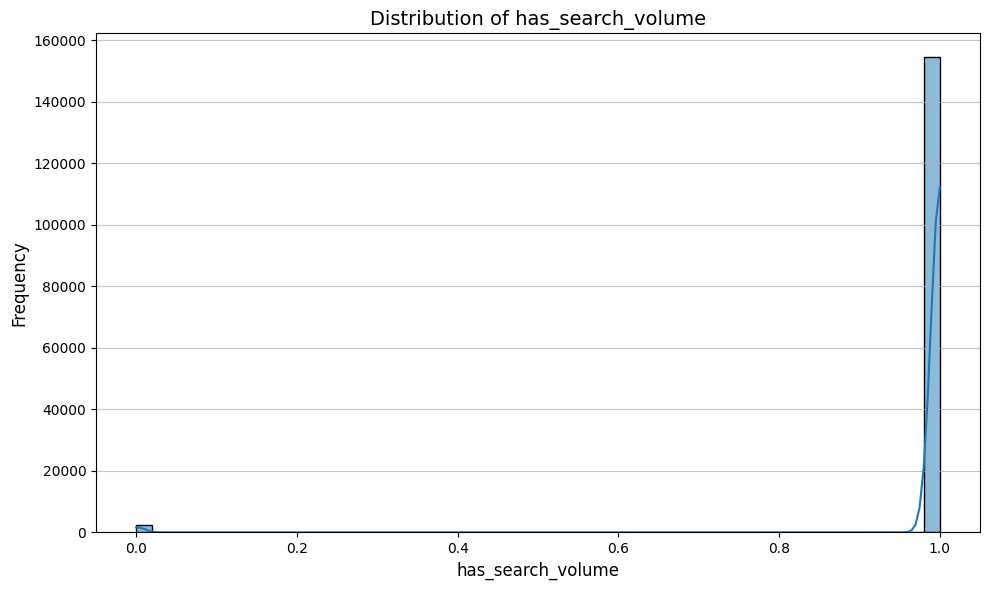

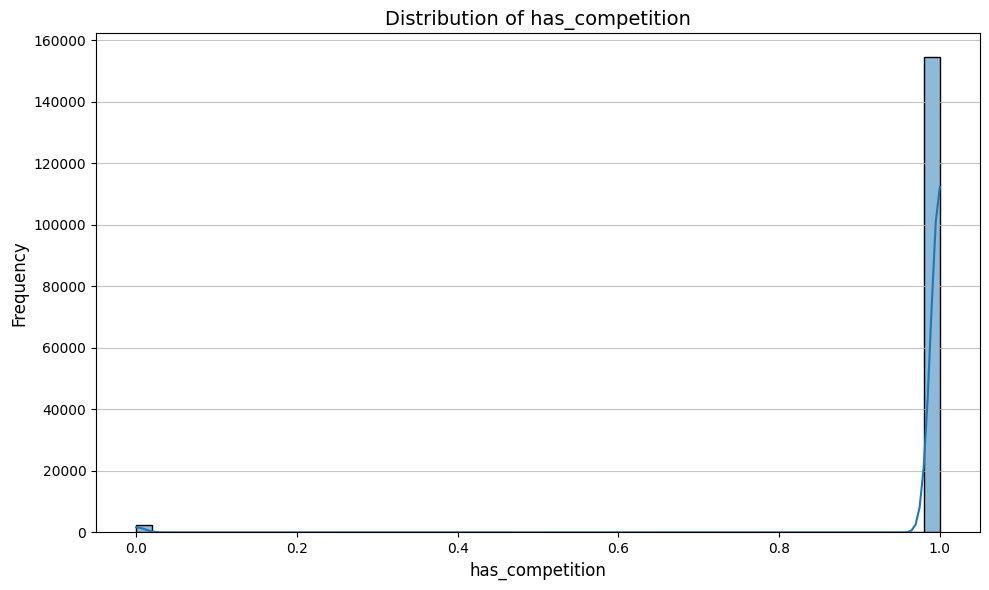

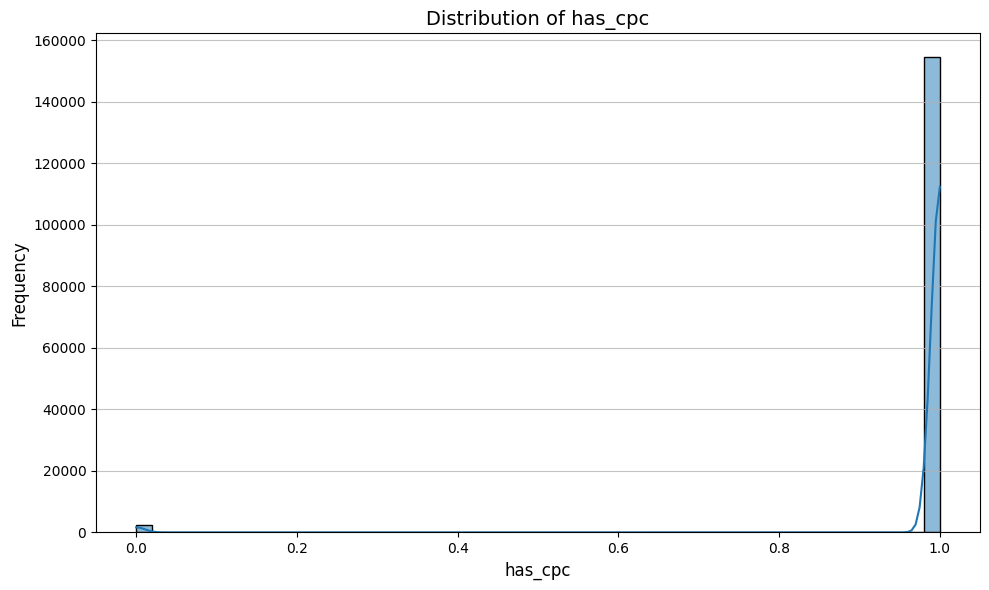

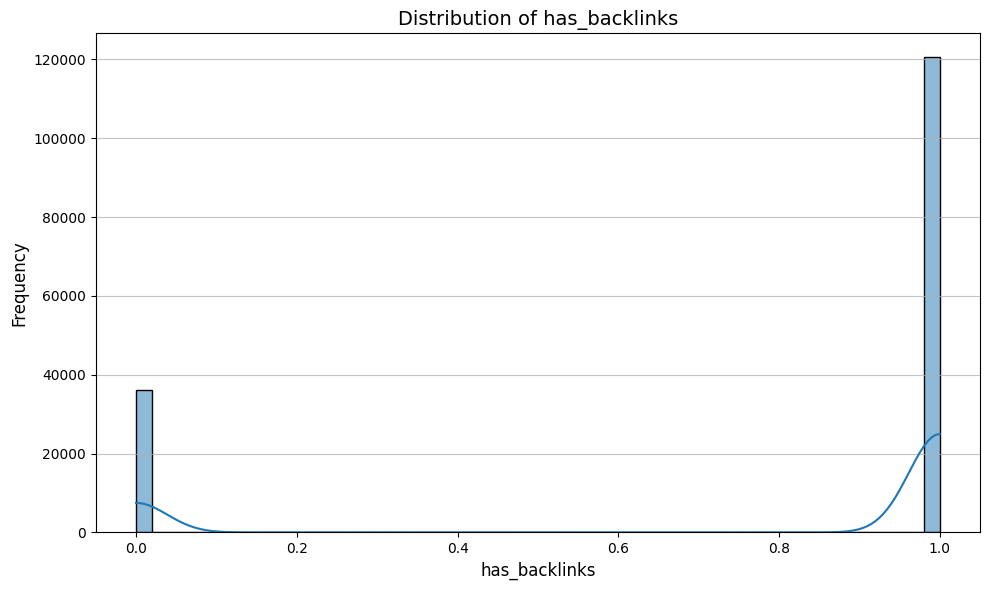

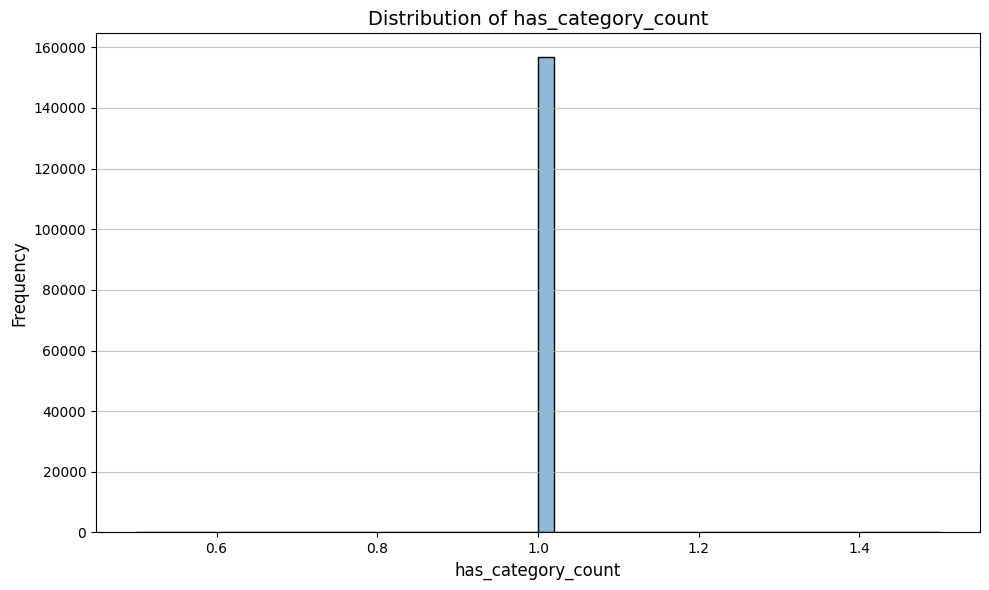

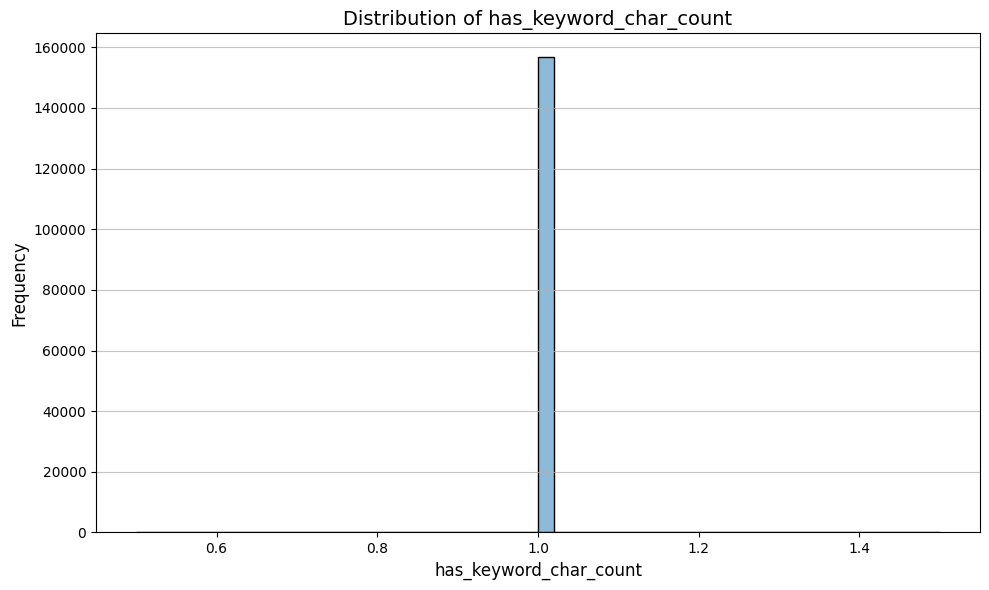

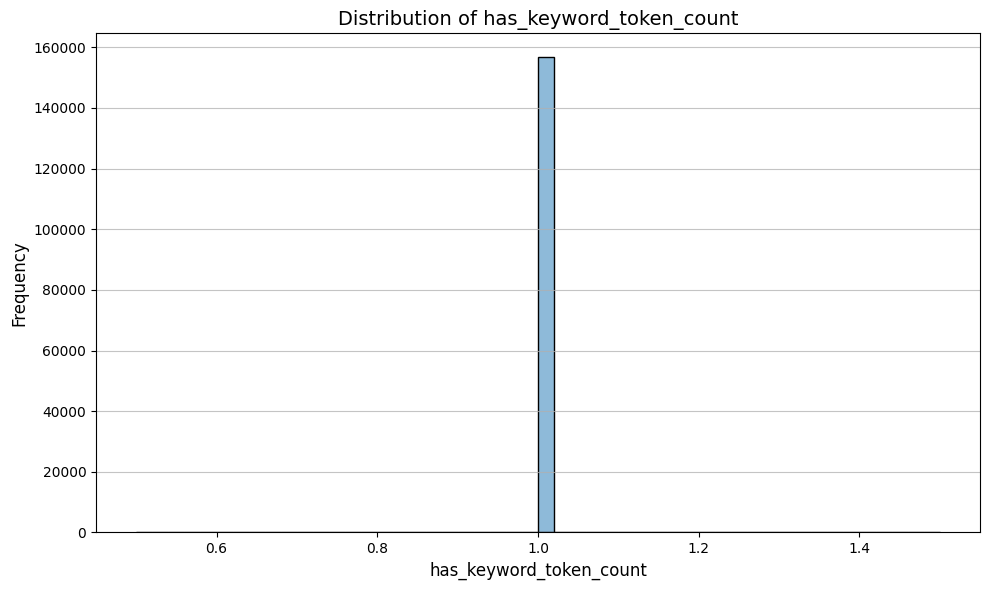

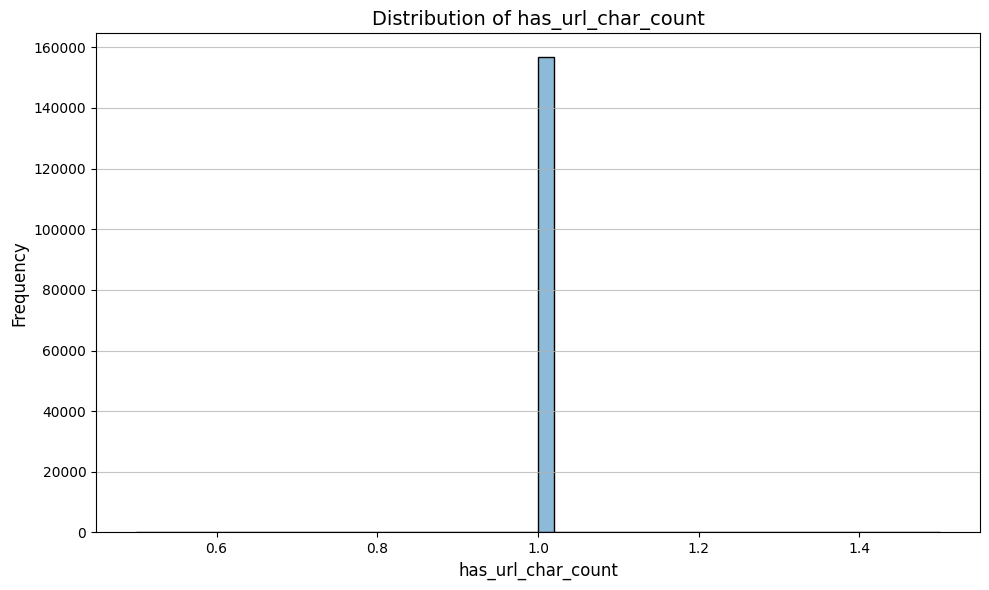

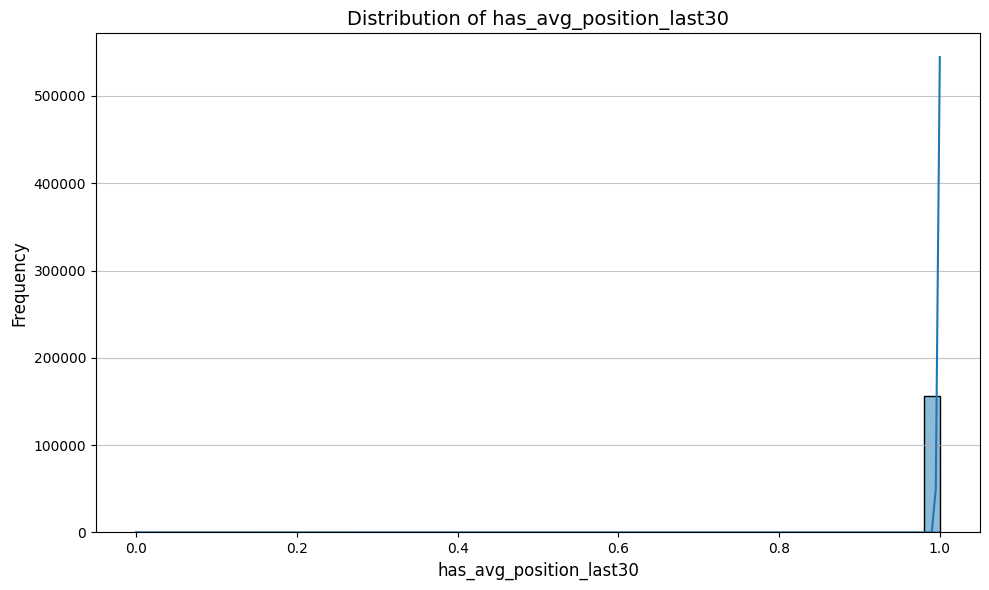

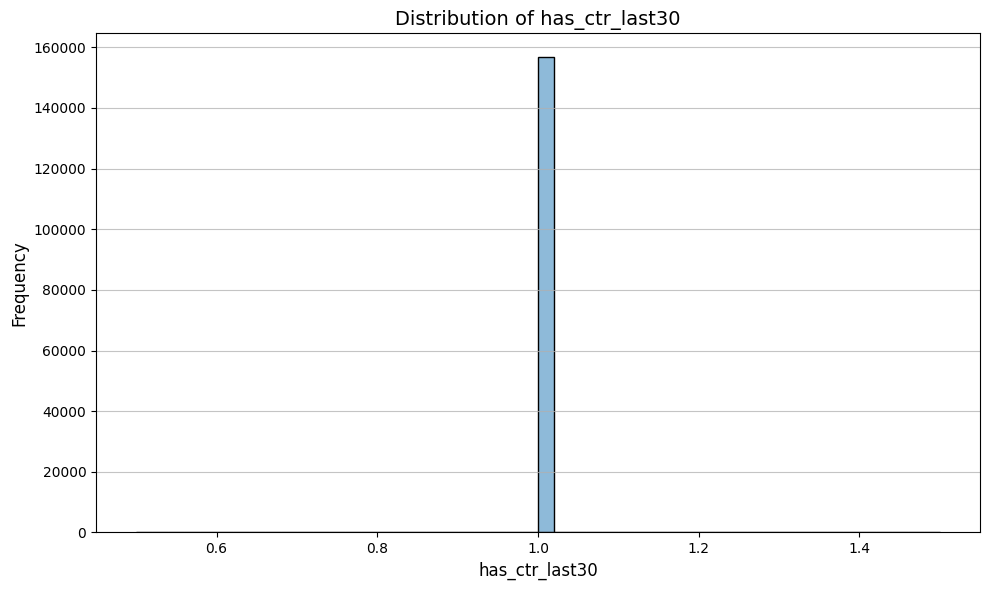

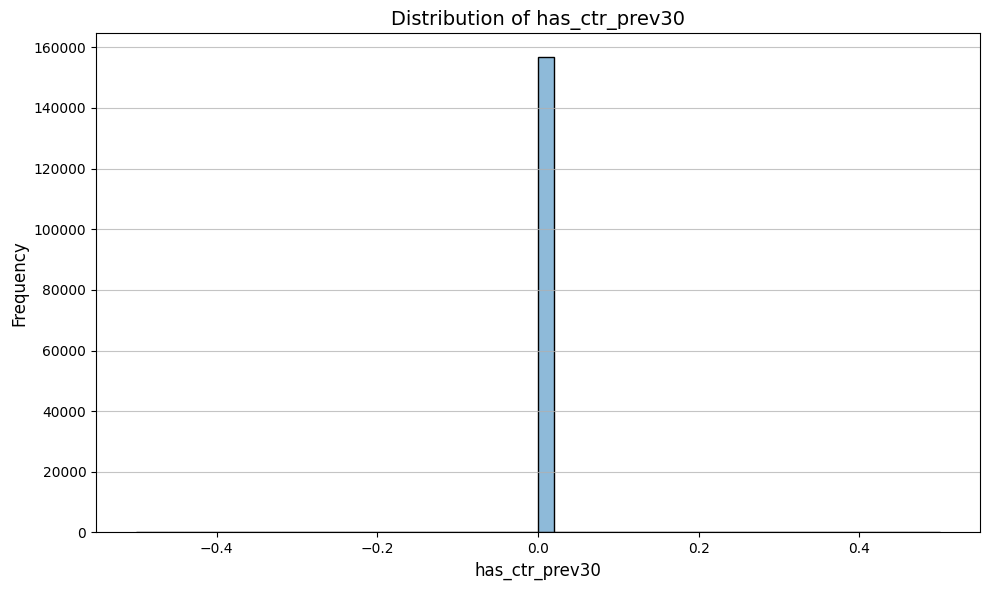

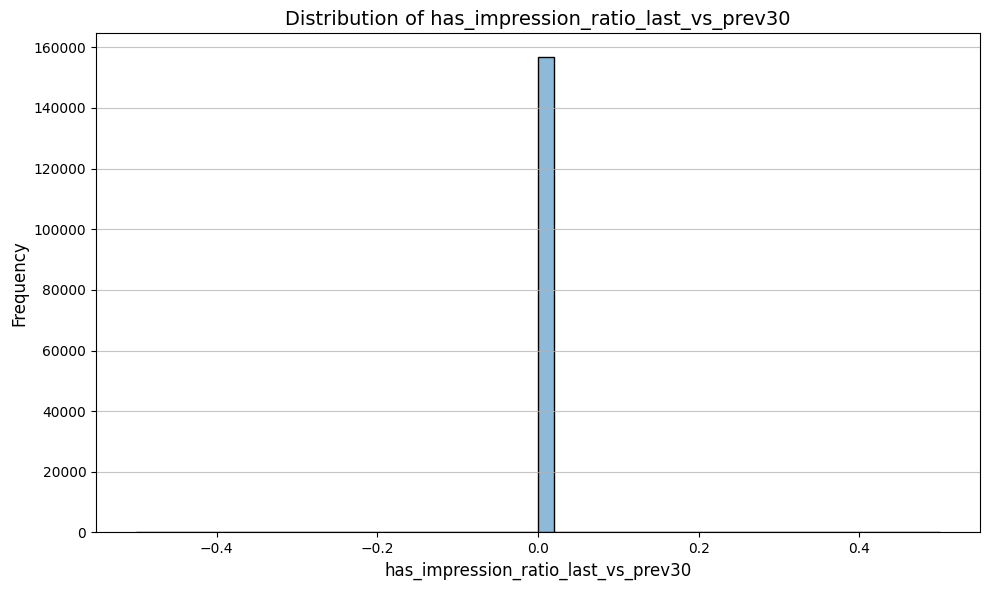

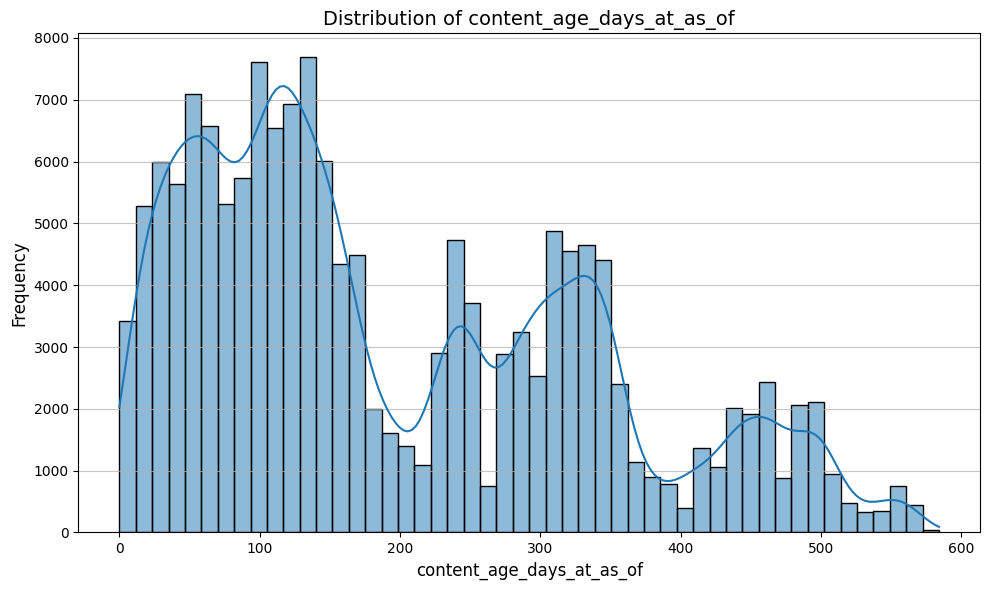

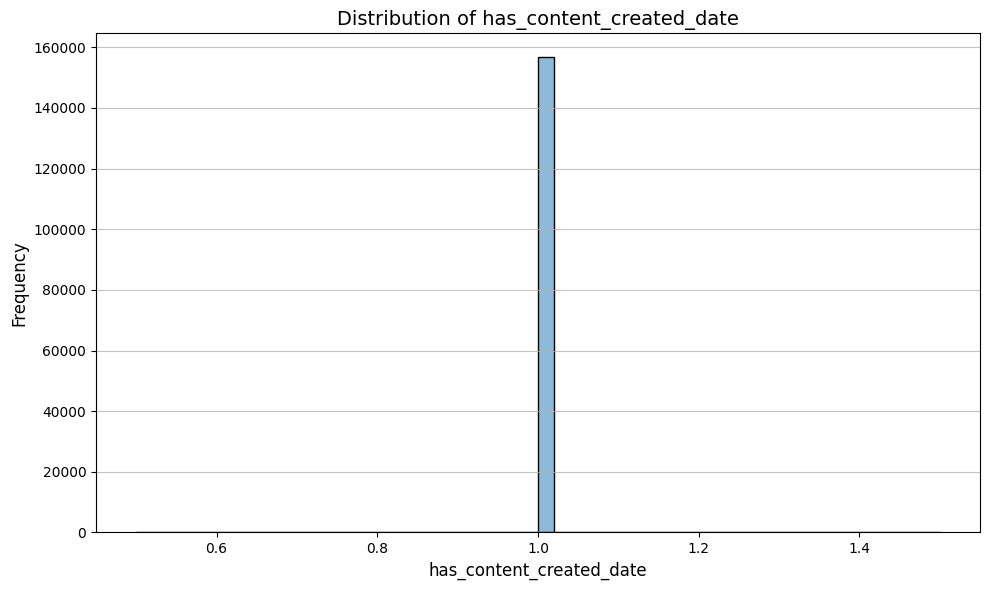

In [12]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define the base path for Google Drive, including the specified 'colab_outputs' subdirectory
drive_path = '/content/gdrive/MyDrive/colab_outputs/'

# Define the target dataset names, prioritizing 'features.parquet' as per user's suggestion
target_files = ['features.parquet', 'baseline_action_score.csv']

df = pd.DataFrame() # Initialize an empty DataFrame
data_file_found = False
loaded_filename = None

for filename in target_files:
    full_path = os.path.join(drive_path, filename)
    if os.path.exists(full_path):
        print(f"Attempting to load data from {full_path}")
        try:
            if full_path.endswith('.csv'):
                df = pd.read_csv(full_path)
            elif full_path.endswith('.parquet'):
                df = pd.read_parquet(full_path)
            print(f"Dataset '{filename}' loaded successfully.")
            data_file_found = True
            loaded_filename = filename
            break # Exit loop once a file is successfully loaded
        except Exception as e:
            print(f"Error loading {full_path}: {e}")
            df = pd.DataFrame() # Ensure df is empty on error
    else:
        print(f"File not found: {full_path}")

if not df.empty:
    print(f"\nSuccessfully loaded: {loaded_filename}")
    print("\nFirst 5 rows of the dataset:")
    display(df.head())

    print("\nDescriptive statistics of the dataset:")
    display(df.describe())

    # Identify numerical columns for distribution analysis
    numerical_cols = df.select_dtypes(include=['number']).columns

    if not numerical_cols.empty:
        print(f"\nGenerating distributions for {len(numerical_cols)} numerical columns. Look for heavy tails.")
        for col in numerical_cols:
            plt.figure(figsize=(10, 6))
            sns.histplot(df[col], kde=True, bins=50) # Using 50 bins for better detail
            plt.title(f'Distribution of {col}', fontsize=14)
            plt.xlabel(col, fontsize=12)
            plt.ylabel('Frequency', fontsize=12)
            plt.grid(axis='y', alpha=0.75)
            plt.tight_layout()
            plt.show()
    else:
        print("No numerical columns found in the dataset to plot distributions.")
else:
    print("DataFrame is empty. No dataset was loaded. Cannot proceed with distribution analysis.")


## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

In [13]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Define the signals to test and the target metric
signals = ['is_declining', 'has_search_volume', 'has_backlinks'] # Updated signals
target_metric = 'content_age_days_at_as_of'

print(f"Performing signal tests against '{target_metric}'.")
print(f"NOTE: The dataset has limited variability in typical outcome metrics (e.g., baseline_score, impressions, clicks) which are constant or NaN.")
print(f"Therefore, we are using '{target_metric}' (content age) as the target for assessing signal behavior, which might not directly reflect a 'good' or 'bad' outcome.")
print("A 'CONFIRMED' verdict here means the signal's 'True' group has a significantly higher age compared to its 'False' group.\n")

results = {}

for signal in signals:
    print(f"--- Signal: {signal} ---")
    if signal not in df.columns:
        print(f"Signal column '{signal}' not found in DataFrame.")
        results[signal] = 'FALSE (Column not found)'
        continue

    # Check signal variability
    signal_counts = df[signal].value_counts()
    print(f"Value counts for {signal}:\n{signal_counts}")

    if len(signal_counts) < 2:
        results[signal] = 'FALSE (Signal is constant - no variation to test)'
        print(f"Verdict: {results[signal]}\n")
        continue

    if target_metric not in df.columns:
        print(f"Target metric column '{target_metric}' not found in DataFrame.")
        results[signal] = 'FALSE (Target metric not found)'
        print(f"Verdict: {results[signal]}\n")
        continue

    # Filter data for True and False cases of the signal by explicitly checking 0 or 1
    true_group = df[df[signal] == 1][target_metric].dropna()
    false_group = df[df[signal] == 0][target_metric].dropna()

    # Check if groups are empty or too small for comparison
    if true_group.empty or false_group.empty or len(true_group) < 2 or len(false_group) < 2:
        results[signal] = 'FALSE (Insufficient data for comparison)'
        print(f"Verdict: {results[signal]}\n")
        continue

    # Perform independent t-test
    # We're interested if the 'True' group has a significantly higher 'content_age_days_at_as_of'
    # than the 'False' group (one-sided test for 'CONFIRMED').
    # We also check for 'OPPOSITE' (significantly lower).
    alpha = 0.05 # Significance level

    t_stat, p_val = stats.ttest_ind(true_group, false_group, equal_var=False) # Welch's t-test

    print(f"Mean {target_metric} for {signal} True: {true_group.mean():.2f}")
    print(f"Mean {target_metric} for {signal} False: {false_group.mean():.2f}")
    print(f"T-statistic: {t_stat:.2f}, P-value: {p_val:.3f}")

    if p_val / 2 < alpha and t_stat > 0: # One-sided test for 'True' > 'False'
        results[signal] = 'CONFIRMED'
    elif p_val / 2 < alpha and t_stat < 0: # One-sided test for 'True' < 'False'
        results[signal] = 'OPPOSITE'
    elif p_val >= alpha:
        results[signal] = 'FALSE (No significant difference)'
    else: # p_val / 2 < alpha but t_stat is around 0 or other complex cases
        results[signal] = 'MIXED (Significant difference but direction unclear or very small)'

    print(f"Verdict: {results[signal]}\n")

print("\n--- Final Verdicts ---")
for signal, verdict in results.items():
    print(f"{signal}: {verdict}")


Performing signal tests against 'content_age_days_at_as_of'.
NOTE: The dataset has limited variability in typical outcome metrics (e.g., baseline_score, impressions, clicks) which are constant or NaN.
Therefore, we are using 'content_age_days_at_as_of' (content age) as the target for assessing signal behavior, which might not directly reflect a 'good' or 'bad' outcome.
A 'CONFIRMED' verdict here means the signal's 'True' group has a significantly higher age compared to its 'False' group.

--- Signal: is_declining ---
Value counts for is_declining:
is_declining
1    113211
0     43567
Name: count, dtype: int64
Mean content_age_days_at_as_of for is_declining True: 200.33
Mean content_age_days_at_as_of for is_declining False: 185.15
T-statistic: 19.04, P-value: 0.000
Verdict: CONFIRMED

--- Signal: has_search_volume ---
Value counts for has_search_volume:
has_search_volume
1    154482
0      2296
Name: count, dtype: int64
Mean content_age_days_at_as_of for has_search_volume True: 194.68
M

## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

In [15]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import pandas as pd
from scipy import stats

# Choose a signal that a hypothetical FlyRank flag might rely on
chosen_signal = 'is_declining'
target_metric = 'content_age_days_at_as_of'

print(f"--- FlyRank Flag-Linked Test: '{chosen_signal}' ---")

# State the hypothetical rule's assumption for this flag
assumption = f"FlyRank assumes that content flagged as '{chosen_signal}' (True) tends to be older (have a higher '{target_metric}') compared to content not flagged as '{chosen_signal}' (False)."
print(f"Hypothetical FlyRank Assumption: {assumption}\n")

# Check if the signal and target metric columns exist
if chosen_signal not in df.columns or target_metric not in df.columns:
    print(f"ERROR: Either '{chosen_signal}' or '{target_metric}' not found in DataFrame.")
else:
    # Filter data for True and False cases of the chosen signal
    true_group = df[df[chosen_signal] == 1][target_metric].dropna()
    false_group = df[df[chosen_signal] == 0][target_metric].dropna()

    # Check for sufficient data
    if true_group.empty or false_group.empty or len(true_group) < 2 or len(false_group) < 2:
        print("RESULT: Insufficient data for comparison.")
    else:
        # Perform independent t-test (Welch's t-test assuming unequal variances)
        t_stat, p_val = stats.ttest_ind(true_group, false_group, equal_var=False)
        alpha = 0.05 # Significance level

        mean_true = true_group.mean()
        mean_false = false_group.mean()

        print(f"Mean '{target_metric}' for '{chosen_signal}' True: {mean_true:.2f} days")
        print(f"Mean '{target_metric}' for '{chosen_signal}' False: {mean_false:.2f} days")
        print(f"T-statistic: {t_stat:.2f}, P-value: {p_val:.3f}")

        # Evaluate if the data supports the assumption (True group mean > False group mean)
        if p_val / 2 < alpha and t_stat > 0: # One-sided test for True > False
            conclusion = "The data **supports** the assumption that content flagged as declining tends to be older."
        else:
            conclusion = "The data **does NOT support** the assumption that content flagged as declining tends to be older (or the difference is not significant in that direction).";

        print(f"\nConclusion:\n{conclusion}")


--- FlyRank Flag-Linked Test: 'is_declining' ---
Hypothetical FlyRank Assumption: FlyRank assumes that content flagged as 'is_declining' (True) tends to be older (have a higher 'content_age_days_at_as_of') compared to content not flagged as 'is_declining' (False).

Mean 'content_age_days_at_as_of' for 'is_declining' True: 200.33 days
Mean 'content_age_days_at_as_of' for 'is_declining' False: 185.15 days
T-statistic: 19.04, P-value: 0.000

Conclusion:
The data **supports** the assumption that content flagged as declining tends to be older.


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

Based on our analysis, content teams should note that **older content is more prone to declining performance**, which reinforces the need for regular content audits and refreshes. Conversely, **newer content tends to attract more search volume and backlinks**, suggesting that fresh, well-promoted content is key for initial impact. This highlights the importance of balancing new content creation with strategic maintenance of existing assets to sustain performance over time.

Visualizing: Older content is more prone to declining performance.


/tmp/ipykernel_399/465975522.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[signal_col].astype(bool), y=df[target_metric], palette='viridis')


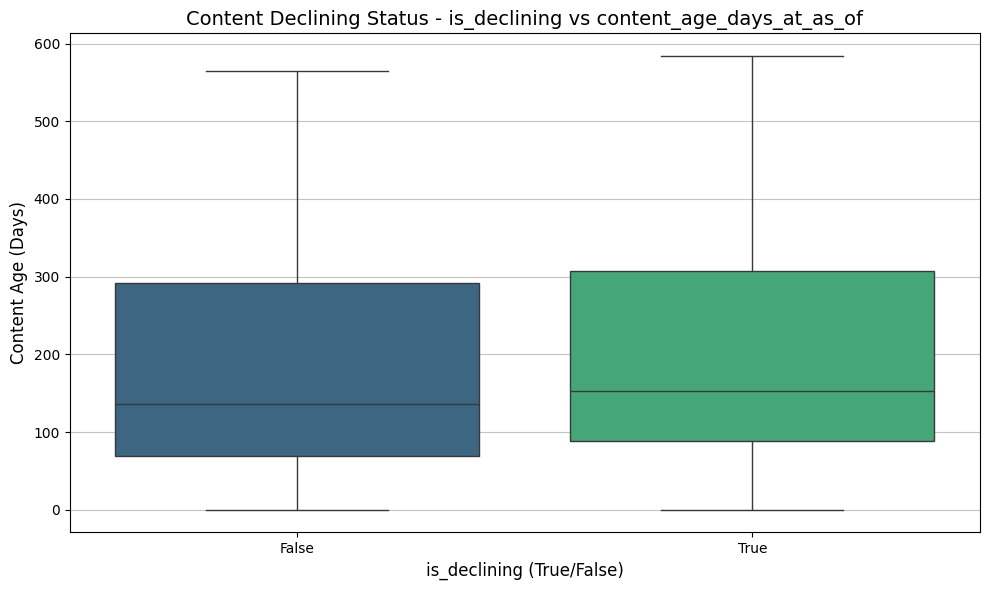


Visualizing: Newer content tends to attract more search volume.


/tmp/ipykernel_399/465975522.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[signal_col].astype(bool), y=df[target_metric], palette='viridis')


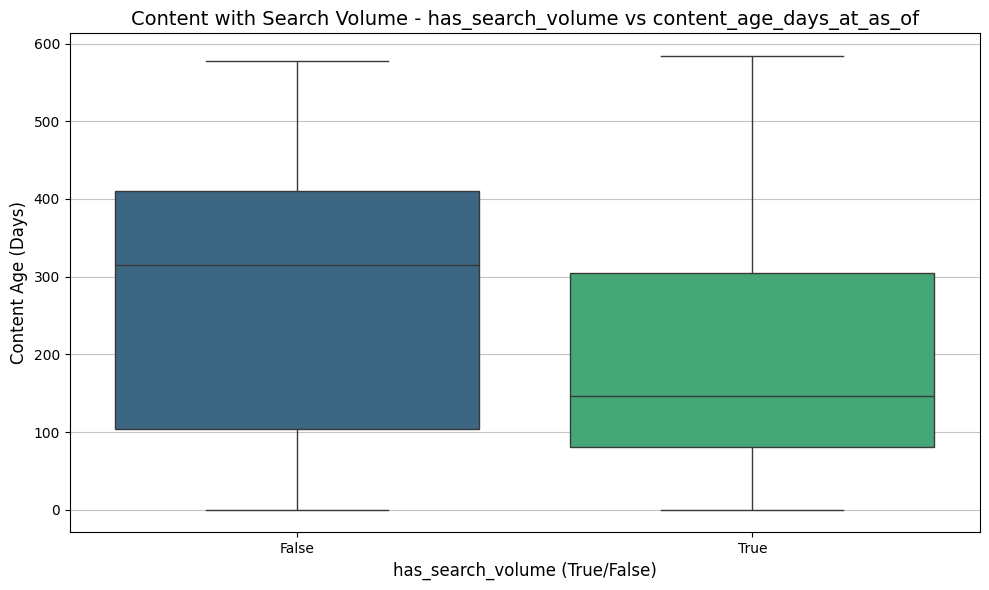


Visualizing: Newer content tends to attract more backlinks.


/tmp/ipykernel_399/465975522.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[signal_col].astype(bool), y=df[target_metric], palette='viridis')


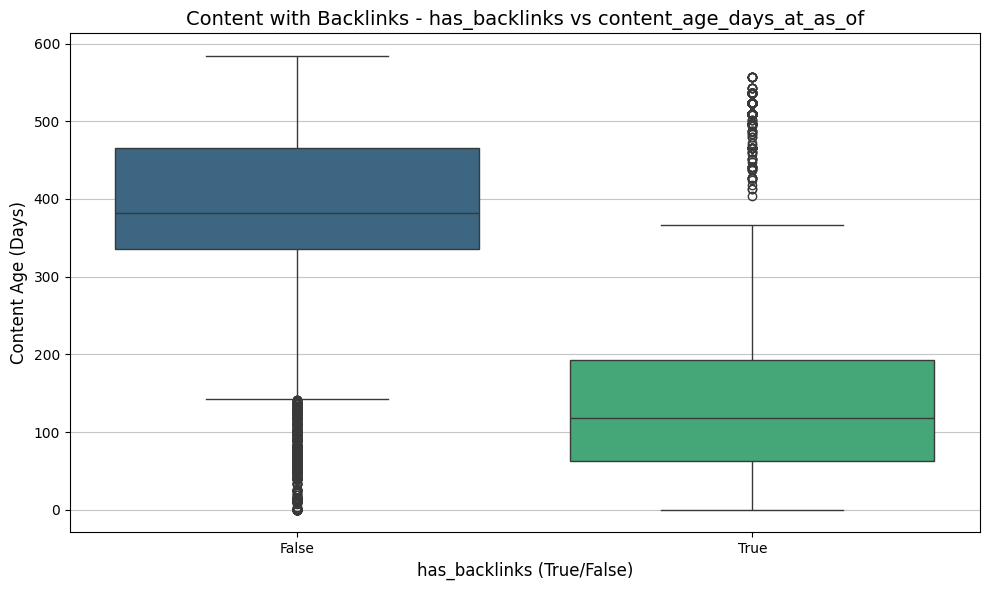

In [17]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import matplotlib.pyplot as plt
import seaborn as sns

# Helper function to plot distributions for True/False groups
def plot_signal_distribution(df, signal_col, target_metric, title_prefix="", y_label="Content Age (Days)"):
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df[signal_col].astype(bool), y=df[target_metric], palette='viridis')
    plt.title(f"{title_prefix} - {signal_col} vs {target_metric}", fontsize=14)
    plt.xlabel(signal_col + ' (True/False)', fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    plt.grid(axis='y', alpha=0.75)
    plt.tight_layout()
    plt.show()

# 1. Older content is more prone to declining performance (is_declining: CONFIRMED)
print("Visualizing: Older content is more prone to declining performance.")
plot_signal_distribution(df, 'is_declining', 'content_age_days_at_as_of', "Content Declining Status")

# 2. Newer content tends to attract more search volume (has_search_volume: OPPOSITE)
print("\nVisualizing: Newer content tends to attract more search volume.")
plot_signal_distribution(df, 'has_search_volume', 'content_age_days_at_as_of', "Content with Search Volume")

# 3. Newer content tends to attract more backlinks (has_backlinks: OPPOSITE)
print("\nVisualizing: Newer content tends to attract more backlinks.")
plot_signal_distribution(df, 'has_backlinks', 'content_age_days_at_as_of', "Content with Backlinks")


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.